# Yolov8 for Quinoa and Foreign Body Detection

---

The YOLO models are well known for their outstanding speed and small size as well as their high precision for object detection tasks with images and videos. These attributes make them the first election for computer vision engineers. Additionally, Yolo models meet the resource constraints present in embedded system, which means they are a good option for mechatronic systems. In this notebook, you will see the implementation of the lattest version of Yolo: Yolov8, however, note that Yolov5, Yolov6, Yolov7 require a similar series of steps to be implemented. The present notebook notebook is heavily based on the [Roboflow's Tutorial for Yolov8](https://colab.research.google.com/github/roboflow-ai/notebooks/blob/main/notebooks/train-yolov8-object-detection-on-custom-dataset.ipynb#scrollTo=iVvaIYEEPOty), and comprehends:

1. [Prepare the environment](#env)
2. [Yolov8](#yolo)
3. [Roboflow Universe](#roboflow)
4. [Prepare a custom dataset](#custom)
5. [Custom Training](#train)
6. [Evaluate Custom Model](#eval)
7. [Inference with Custom Model](#inference)
7. [Deploy model](#deploy)


## 1. Prepare the environment
<a name="env"></a>

**Confirm GPU access**

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Mon Aug 26 04:18:27 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA L4                      Off | 00000000:00:03.0 Off |                    0 |
| N/A   53C    P8              13W /  72W |      1MiB / 23034MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

**Install libraries**

In [2]:
from sklearn.model_selection import train_test_split
import time
import shutil
import os

**Define system parameters**

In [3]:
HOME = os.getcwd()
print(HOME)

/content


## 2. YOLOv8
<a name="yolo"></a>

YOLOv8 can be installed in two ways – from the Github source and via pip. We will prefer PIP package since this is the easiest, however, you should install it from Github if you notice package collisions or malfunctions.

In [4]:
# Pip install method (recommended)

!pip install ultralytics==8.1.24

from IPython import display
display.clear_output()

import ultralytics
ultralytics.checks()

from ultralytics import YOLO

from IPython.display import display, Image

Ultralytics YOLOv8.1.24 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Setup complete ✅ (12 CPUs, 53.0 GB RAM, 33.7/78.2 GB disk)


In [ ]:
# Git clone method (for development)

# %cd {HOME}
# !git clone github.com/ultralytics/ultralytics
# %cd {HOME}/ultralytics
# !pip install -e .

# from IPython import display
# display.clear_output()

# import ultralytics
# ultralytics.checks()

# from ultralytics import YOLO

# from IPython.display import display, Image

#### CLI Basics

If you want to train, validate or run inference on models and don't need to make any modifications to the code, using YOLO command line interface is the easiest way to get started. Read more about CLI in [Ultralytics YOLO Docs](https://docs.ultralytics.com/usage/cli/).

```
yolo task=detect    mode=train    model=yolov8n.yaml      args...
          classify       predict        yolov8n-cls.yaml  args...
          segment        val            yolov8n-seg.yaml  args...
                         export         yolov8n.pt        format=onnx  args...
```

#### Inference with Pre-trained COCO Model

#### 💻 CLI

`yolo mode=predict` runs YOLOv8 inference on a variety of sources, downloading models automatically from the latest YOLOv8 release, and saving results to `runs/predict`.

In [ ]:
%cd {HOME}
!yolo task=detect mode=predict model=yolov8n.pt conf=0.25 source='https://media.roboflow.com/notebooks/examples/dog.jpeg' save=True

/content
100% 6.23M/6.23M [00:00<00:00, 51.4MB/s]

2023-10-15 15:09:36.237653: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-10-15 15:09:36.292246: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-10-15 15:09:37.178189: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
Ultralytics YOLOv8.0.20 🚀 Python-3.10.12 torch-2.0.1+cu118 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
YOLOv8n summary (fused): 168 layers, 3151904 parameters, 0 gradients, 8.7 GFLOPs
100% 104k/104k [00

/content


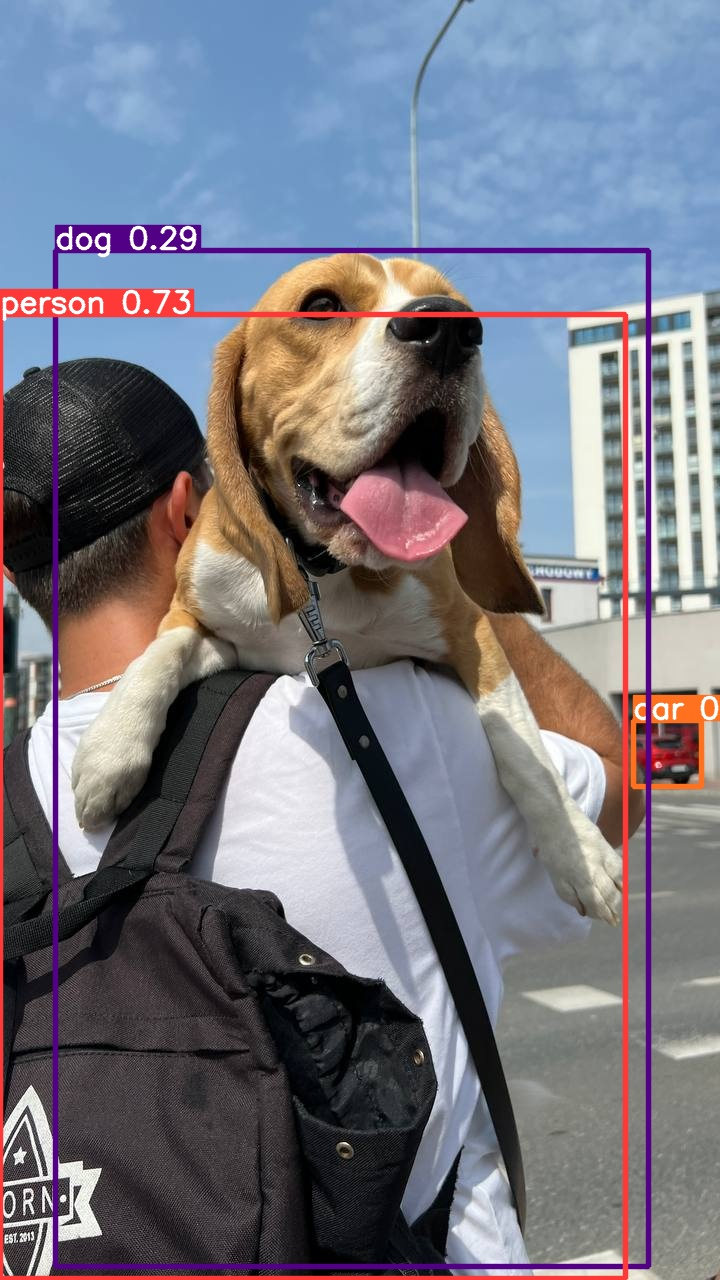

In [ ]:
%cd {HOME}
Image(filename='runs/detect/predict/dog.jpeg', height=600)

#### 🐍 Python SDK

The simplest way of simply using YOLOv8 directly in a Python environment.

In [ ]:
model = YOLO(f'{HOME}/yolov8n.pt')
results = model.predict(source='https://media.roboflow.com/notebooks/examples/dog.jpeg', conf=0.25)

Ultralytics YOLOv8.0.20 🚀 Python-3.10.12 torch-2.0.1+cu118 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)
YOLOv8n summary (fused): 168 layers, 3151904 parameters, 0 gradients, 8.7 GFLOPs
Found https://media.roboflow.com/notebooks/examples/dog.jpeg locally at dog.jpeg


In [ ]:
results[0].boxes.xyxy

tensor([[   0.,  314.,  625., 1278.],
        [  55.,  250.,  648., 1266.],
        [ 633.,  720.,  701.,  786.]], device='cuda:0')

In [ ]:
results[0].boxes.conf

tensor([0.72689, 0.28990, 0.28401], device='cuda:0')

In [ ]:
results[0].boxes.cls

tensor([ 0., 16.,  2.], device='cuda:0')

## 3. Roboflow Universe
<a name="roboflow"></a>

Need data for your project? Before spending time on annotating, check out Roboflow Universe, a repository of more than 110,000 open-source datasets that you can use in your projects. You'll find datasets containing everything from annotated cracks in concrete to plant images with disease annotations.


[![Roboflow Universe](https://media.roboflow.com/notebooks/template/uni-banner-frame.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672878480290)](https://universe.roboflow.com/)

Building a custom dataset can be a painful process. It might take dozens or even hundreds of hours to collect images, label them, and export them in the proper format. Fortunately, Roboflow makes this process as straightforward and fast as possible. Let me show you how!

### Step 1: Creating project

Before you start, you need to create a Roboflow [account](https://app.roboflow.com/login). Once you do that, you can create a new project in the Roboflow [dashboard](https://app.roboflow.com/). Keep in mind to choose the right project type. In our case, Object Detection.

<div align="center">
  <img
    width="640"
    src="https://media.roboflow.com/preparing-custom-dataset-example/creating-project.gif?ik-sdk-version=javascript-1.4.3&updatedAt=1672929799852"
  >
</div>

### Step 2: Uploading images

Next, add the data to your newly created project. You can do it via API or through our [web interface](https://docs.roboflow.com/adding-data/object-detection).

If you drag and drop a directory with a dataset in a supported format, the Roboflow dashboard will automatically read the images and annotations together.

<div align="center">
  <img
    width="640"
    src="https://media.roboflow.com/preparing-custom-dataset-example/uploading-images.gif?ik-sdk-version=javascript-1.4.3&updatedAt=1672929808290"
  >
</div>

### Step 3: Labeling

If you only have images, you can label them in [Roboflow Annotate](https://docs.roboflow.com/annotate).

<div align="center">
  <img
    width="640"
    src="https://user-images.githubusercontent.com/26109316/210901980-04861efd-dfc0-4a01-9373-13a36b5e1df4.gif"
  >
</div>

### Step 4: Generate new dataset version

Now that we have our images and annotations added, we can Generate a Dataset Version. When Generating a Version, you may elect to add preprocessing and augmentations. This step is completely optional, however, it can allow you to significantly improve the robustness of your model.

<div align="center">
  <img
    width="640"
    src="https://media.roboflow.com/preparing-custom-dataset-example/generate-new-version.gif?ik-sdk-version=javascript-1.4.3&updatedAt=1673003597834"
  >
</div>

### Step 5: Exporting dataset

Once the dataset version is generated, we have a hosted dataset we can load directly into our notebook for easy training. Click `Export` and select the `YOLO v5 PyTorch` dataset format.

<div align="center">
  <img
    width="640"
    src="https://media.roboflow.com/preparing-custom-dataset-example/export.gif?ik-sdk-version=javascript-1.4.3&updatedAt=1672943313709"
  >
</div>




In [ ]:
# !mkdir {HOME}/datasets
# %cd {HOME}/datasets

# !pip install roboflow --quiet

# from roboflow import Roboflow
# rf = Roboflow(api_key="YOUR_API_KEY")
# project = rf.workspace("roboflow-jvuqo").project("football-players-detection-3zvbc")
# dataset = project.version(1).download("yolov8")

## 4. Prepare a custom dataset
<a name="custom"></a>

Even though roboflow has many utilities to work on an object detection project, its main disadvantage is that it limits the number of images to work with (10,000 images as for 12 October) per project. The tool can also cause problems if their servers are down or their online resources are inaccessible. Therefore, it's useful to know how to work with a dataset hosted or labelled with distinct tools. In the following case, we will work with a dataset hosted on Gdrive.

In [5]:
from google.colab import drive

# Mount Gdrive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [6]:
DATASET_NAME = "augmented_dataset_2"
GDRIVE_DATASET_PATH = os.path.join("/content/gdrive/MyDrive/Datasets 📊/QuinoaInspector/",DATASET_NAME+".zip",)
LOCAL_DATASET_PATH = os.path.join("/content/", DATASET_NAME) # folder for the dataset

!unzip "$GDRIVE_DATASET_PATH" -d "$LOCAL_DATASET_PATH" > /dev/null

In [7]:
%cd {LOCAL_DATASET_PATH}

# Read images and annotations
images = [os.path.join(LOCAL_DATASET_PATH, x) for x in os.listdir(os.path.join(LOCAL_DATASET_PATH)) if x[-3:] == "png"]
annotations = [os.path.join(LOCAL_DATASET_PATH, x) for x in os.listdir(os.path.join(LOCAL_DATASET_PATH)) if x[-3:] == "txt"]

images.sort()
annotations.sort()

# Split the dataset into train-valid-test splits
train_images, val_images, train_annotations, val_annotations = train_test_split(images, annotations, test_size = 0.20, random_state = 1)
val_images, test_images, val_annotations, test_annotations = train_test_split(val_images, val_annotations, test_size = 0.0001, random_state = 1)

# Create the folders to keep the splits. First, check if the subfolders already exists
if os.path.exists(os.path.join(LOCAL_DATASET_PATH, "train")):
  shutil.rmtree(os.path.join(LOCAL_DATASET_PATH, "train"))
if os.path.exists(os.path.join(LOCAL_DATASET_PATH, "val")):
  shutil.rmtree(os.path.join(LOCAL_DATASET_PATH, "val"))
if os.path.exists(os.path.join(LOCAL_DATASET_PATH, "test")):
  shutil.rmtree(os.path.join(LOCAL_DATASET_PATH, "test"))

!mkdir train test val train/images train/labels test/images test/labels val/images val/labels

# Utility function to move images/labels to their respective datasets
def move_files_to_folder(list_of_files, destination_folder):
  for f in list_of_files:
    try:
      shutil.copy(f, destination_folder)
    except:
      print(f)
      assert False

# Move the splits into their folders
move_files_to_folder(train_images, 'train/images/')
move_files_to_folder(val_images, 'val/images/')
move_files_to_folder(test_images, 'test/images/')
move_files_to_folder(train_annotations, 'train/labels/')
move_files_to_folder(val_annotations, 'val/labels/')
move_files_to_folder(test_annotations, 'test/labels/')

/content/augmented_dataset_2


In [8]:
# IPython is a great tool for interactive shells as Notebooks. It comes with
# many utilities and we will use register_line_cell_magic
# to overwrite a file directly from a Colab cell. Otherwise, we would need to
# download and upload the file. We define writetemplate to customize iPython
# writefile
from IPython.core.magic import register_line_cell_magic

@register_line_cell_magic
def writetemplate(line, cell):
    with open(line, 'w') as f:
        f.write(cell.format(**globals()))

In [ ]:
# # Change the location of the training and validation subsets. The rest
# # of the file remains equal.

# %%writetemplate data.yaml

# train: /content/{DATASET_NAME}/train/images
# val: /content/{DATASET_NAME}/val/images
# test: /content/{DATASET_NAME}/test/images

# nc: 8
# names: ["white","dark","red","larva","rat faeces","stem","clod","stone"]

In [9]:
# Change the location of the training and validation subsets. The rest
# of the file remains equal.

%%writetemplate data.yaml

train: /content/{DATASET_NAME}/train/images
val: /content/{DATASET_NAME}/val/images
test: /content/{DATASET_NAME}/test/images

nc: 5
names: ["larva","rat faeces","stem","clod","stone"]

In [10]:
!cat data.yaml


train: /content/augmented_dataset_2/train/images
val: /content/augmented_dataset_2/val/images
test: /content/augmented_dataset_2/test/images

nc: 5
names: ["larva","rat faeces","stem","clod","stone"]


## 5. Custom Training
<a name="train"></a>

In the following cell, we setup some of the main parameters for training the model. Nevertheless, we can tune more options as defined in this [link](https://docs.ultralytics.com/usage/cfg/#train). Try to give it a read and check if changing hyperparameters such as the optimizer, epochs, batch size, get better results.

In [11]:
# Define parameters here
MODE = "train" # options: train, val, test
MODEL_NAME = "yolov8s" # options:yolov8s, yolov8n, yolov8m, yolov8x, yolov8l
MODEL_FILE = os.path.join(HOME, MODEL_NAME+".pt")
EPOCHS = 10
BATCH_SIZE = 16
GDRIVE_CHECKPOINTS_PATH = os.path.join("/content/gdrive/Shareddrives/QuinoaInspector 🌾/experiments/")
EXPERIMENT_NAME = MODEL_NAME + "_id4" # Change here the experiment name
FINAL_GDRIVE_PATH = os.path.join(GDRIVE_CHECKPOINTS_PATH, EXPERIMENT_NAME)

if os.path.exists(FINAL_GDRIVE_PATH):
  shutil.rmtree(FINAL_GDRIVE_PATH)


In [12]:
%cd {HOME}

!yolo task=detect mode={MODE} model={MODEL_FILE} data={LOCAL_DATASET_PATH}/data.yaml epochs={EPOCHS} imgsz=800 plots=True batch={BATCH_SIZE} project="$GDRIVE_CHECKPOINTS_PATH" name={EXPERIMENT_NAME}

/content
100% 21.5M/21.5M [00:00<00:00, 321MB/s]
New https://pypi.org/project/ultralytics/8.2.82 available 😃 Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.1.24 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
engine/trainer: task=detect, mode=train, model=/content/yolov8s.pt, data=/content/augmented_dataset_2/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=800, save=True, save_period=-1, cache=False, device=None, workers=8, project=/content/gdrive/Shareddrives/QuinoaInspector 🌾/experiments/, name=yolov8s_id4, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream

In [ ]:
!ls "$FINAL_GDRIVE_PATH"

args.yaml					     PR_curve.png	    val_batch0_pred.jpg
confusion_matrix_normalized.png			     R_curve.png	    val_batch1_labels.jpg
confusion_matrix.png				     results.csv	    val_batch1_pred.jpg
events.out.tfevents.1714873615.d149c96c85cd.11443.0  results.png	    val_batch2_labels.jpg
F1_curve.png					     train_batch0.jpg	    val_batch2_pred.jpg
labels_correlogram.jpg				     train_batch1.jpg	    weights
labels.jpg					     train_batch2.jpg
P_curve.png					     val_batch0_labels.jpg


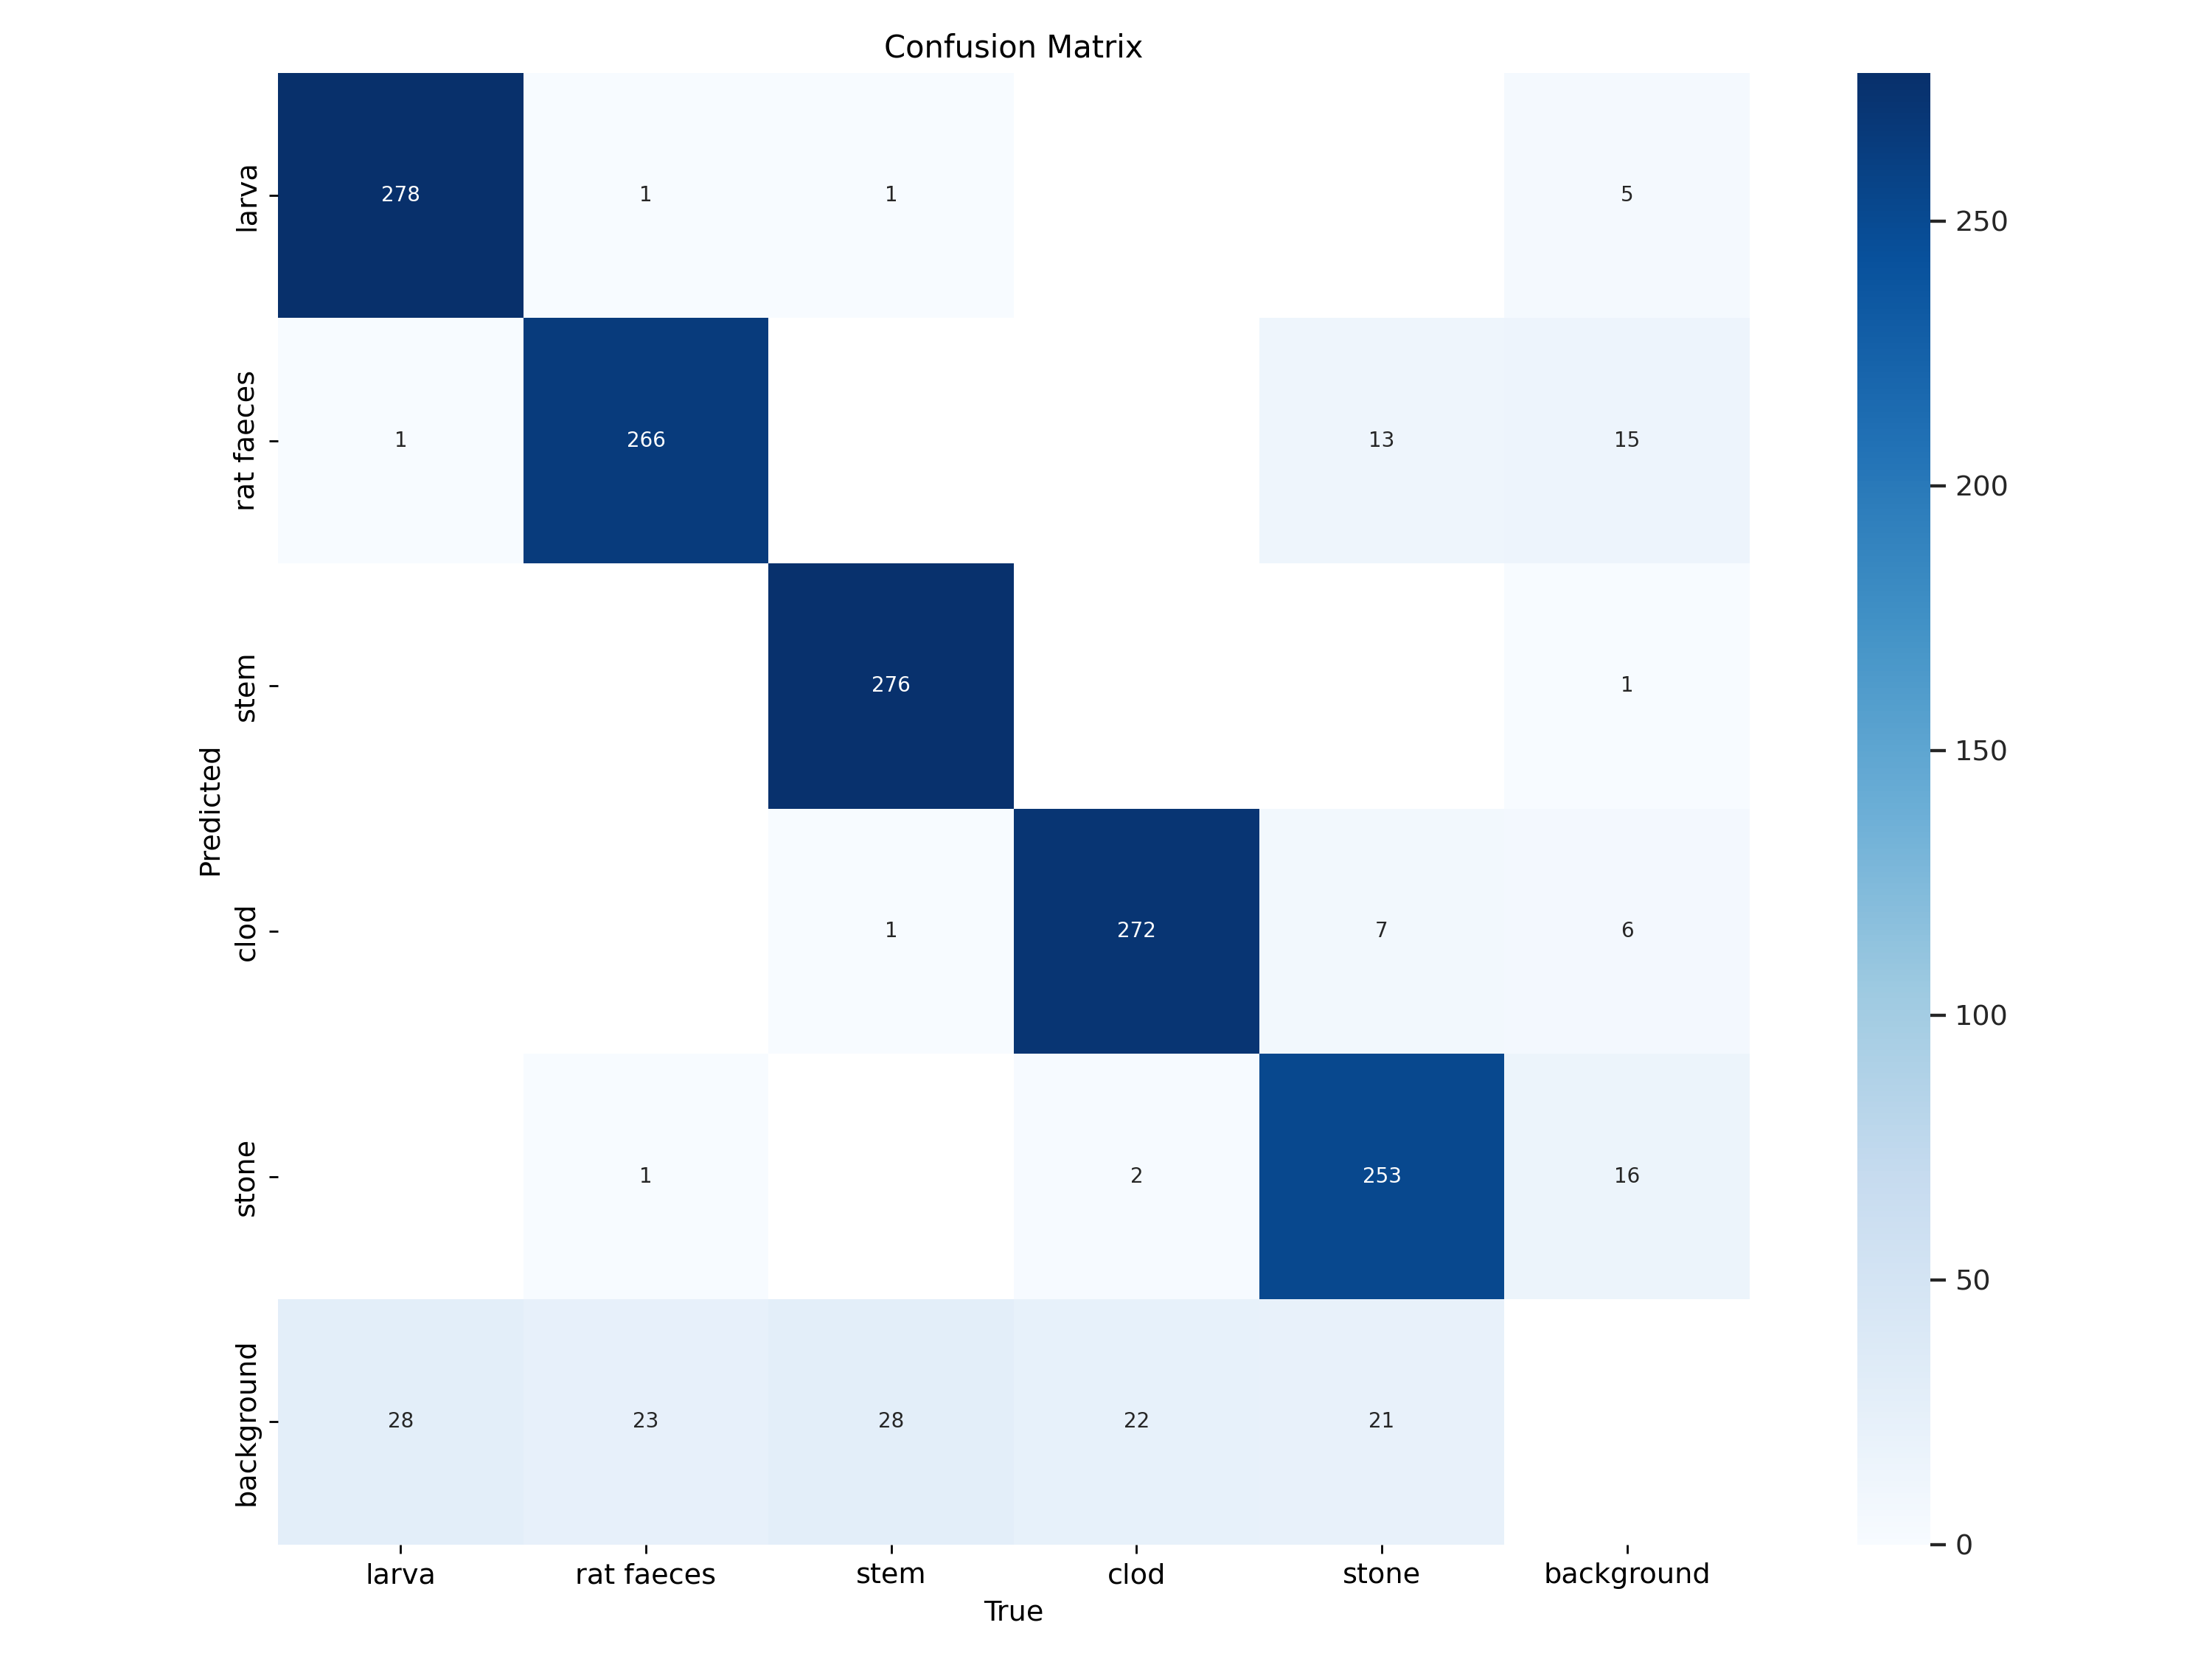

In [13]:
Image(filename=f'{FINAL_GDRIVE_PATH}/confusion_matrix.png', width=600)

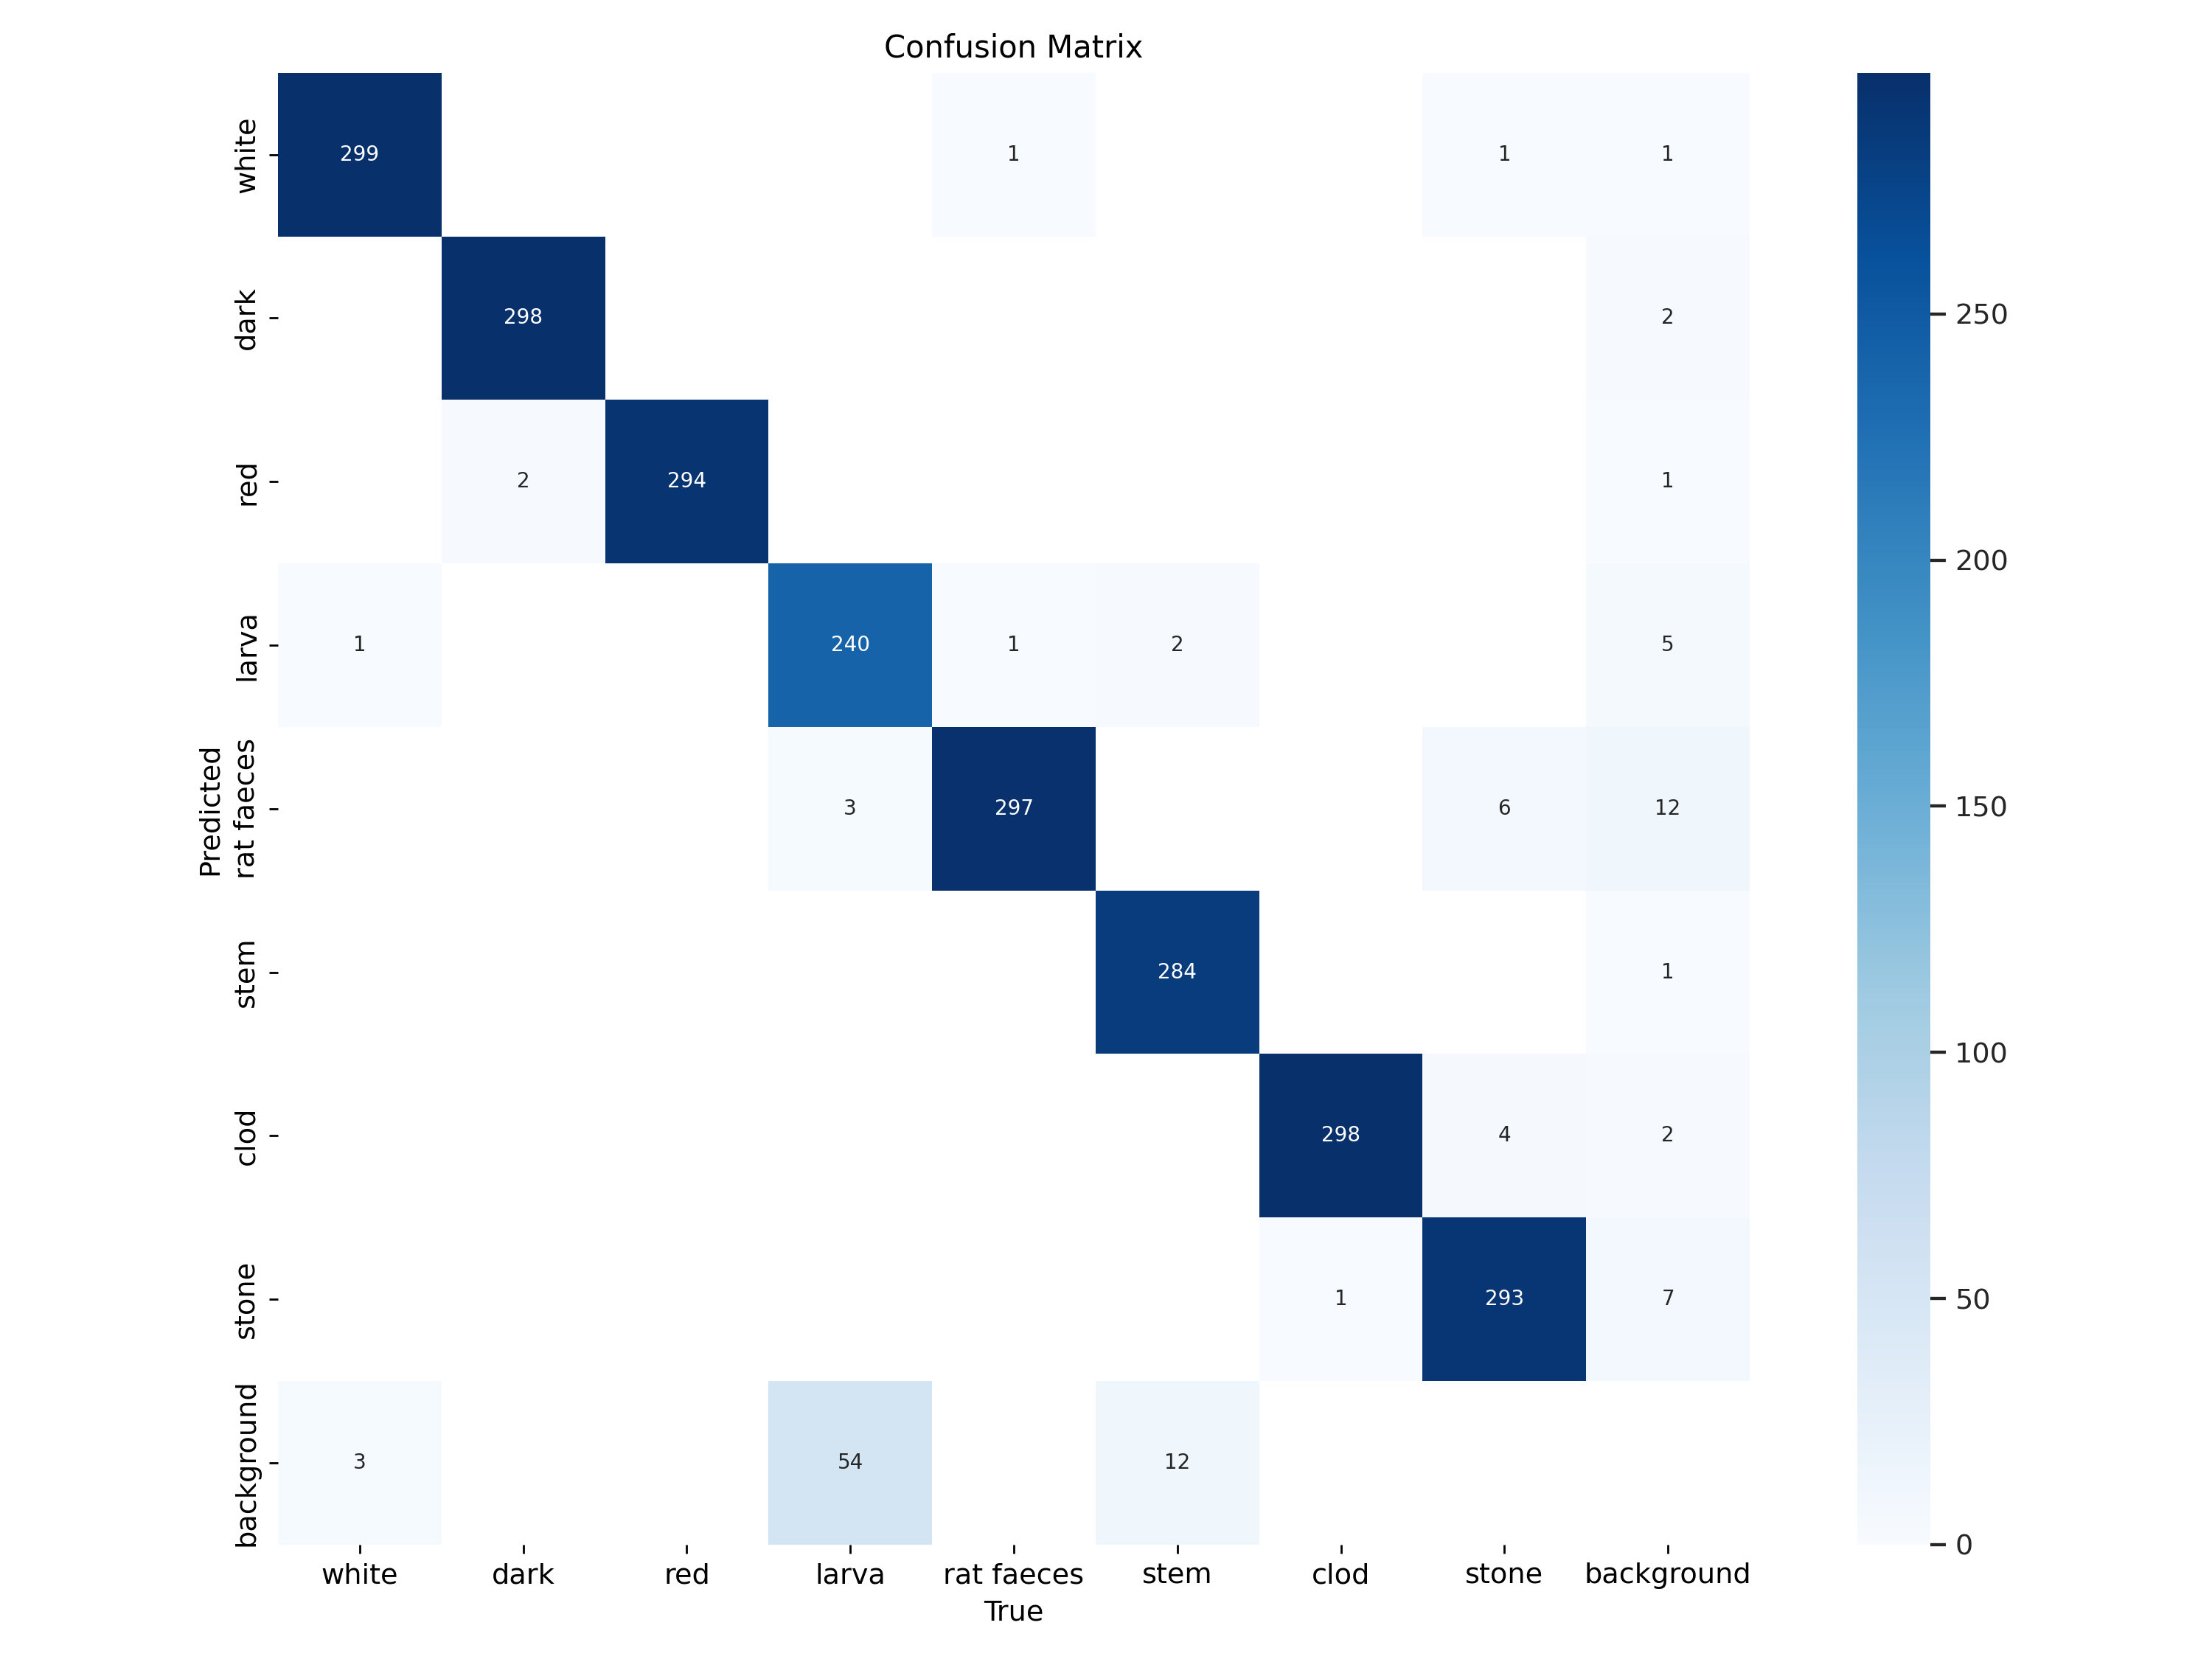

In [ ]:
Image(filename=f'{FINAL_GDRIVE_PATH}/confusion_matrix.png', width=600)

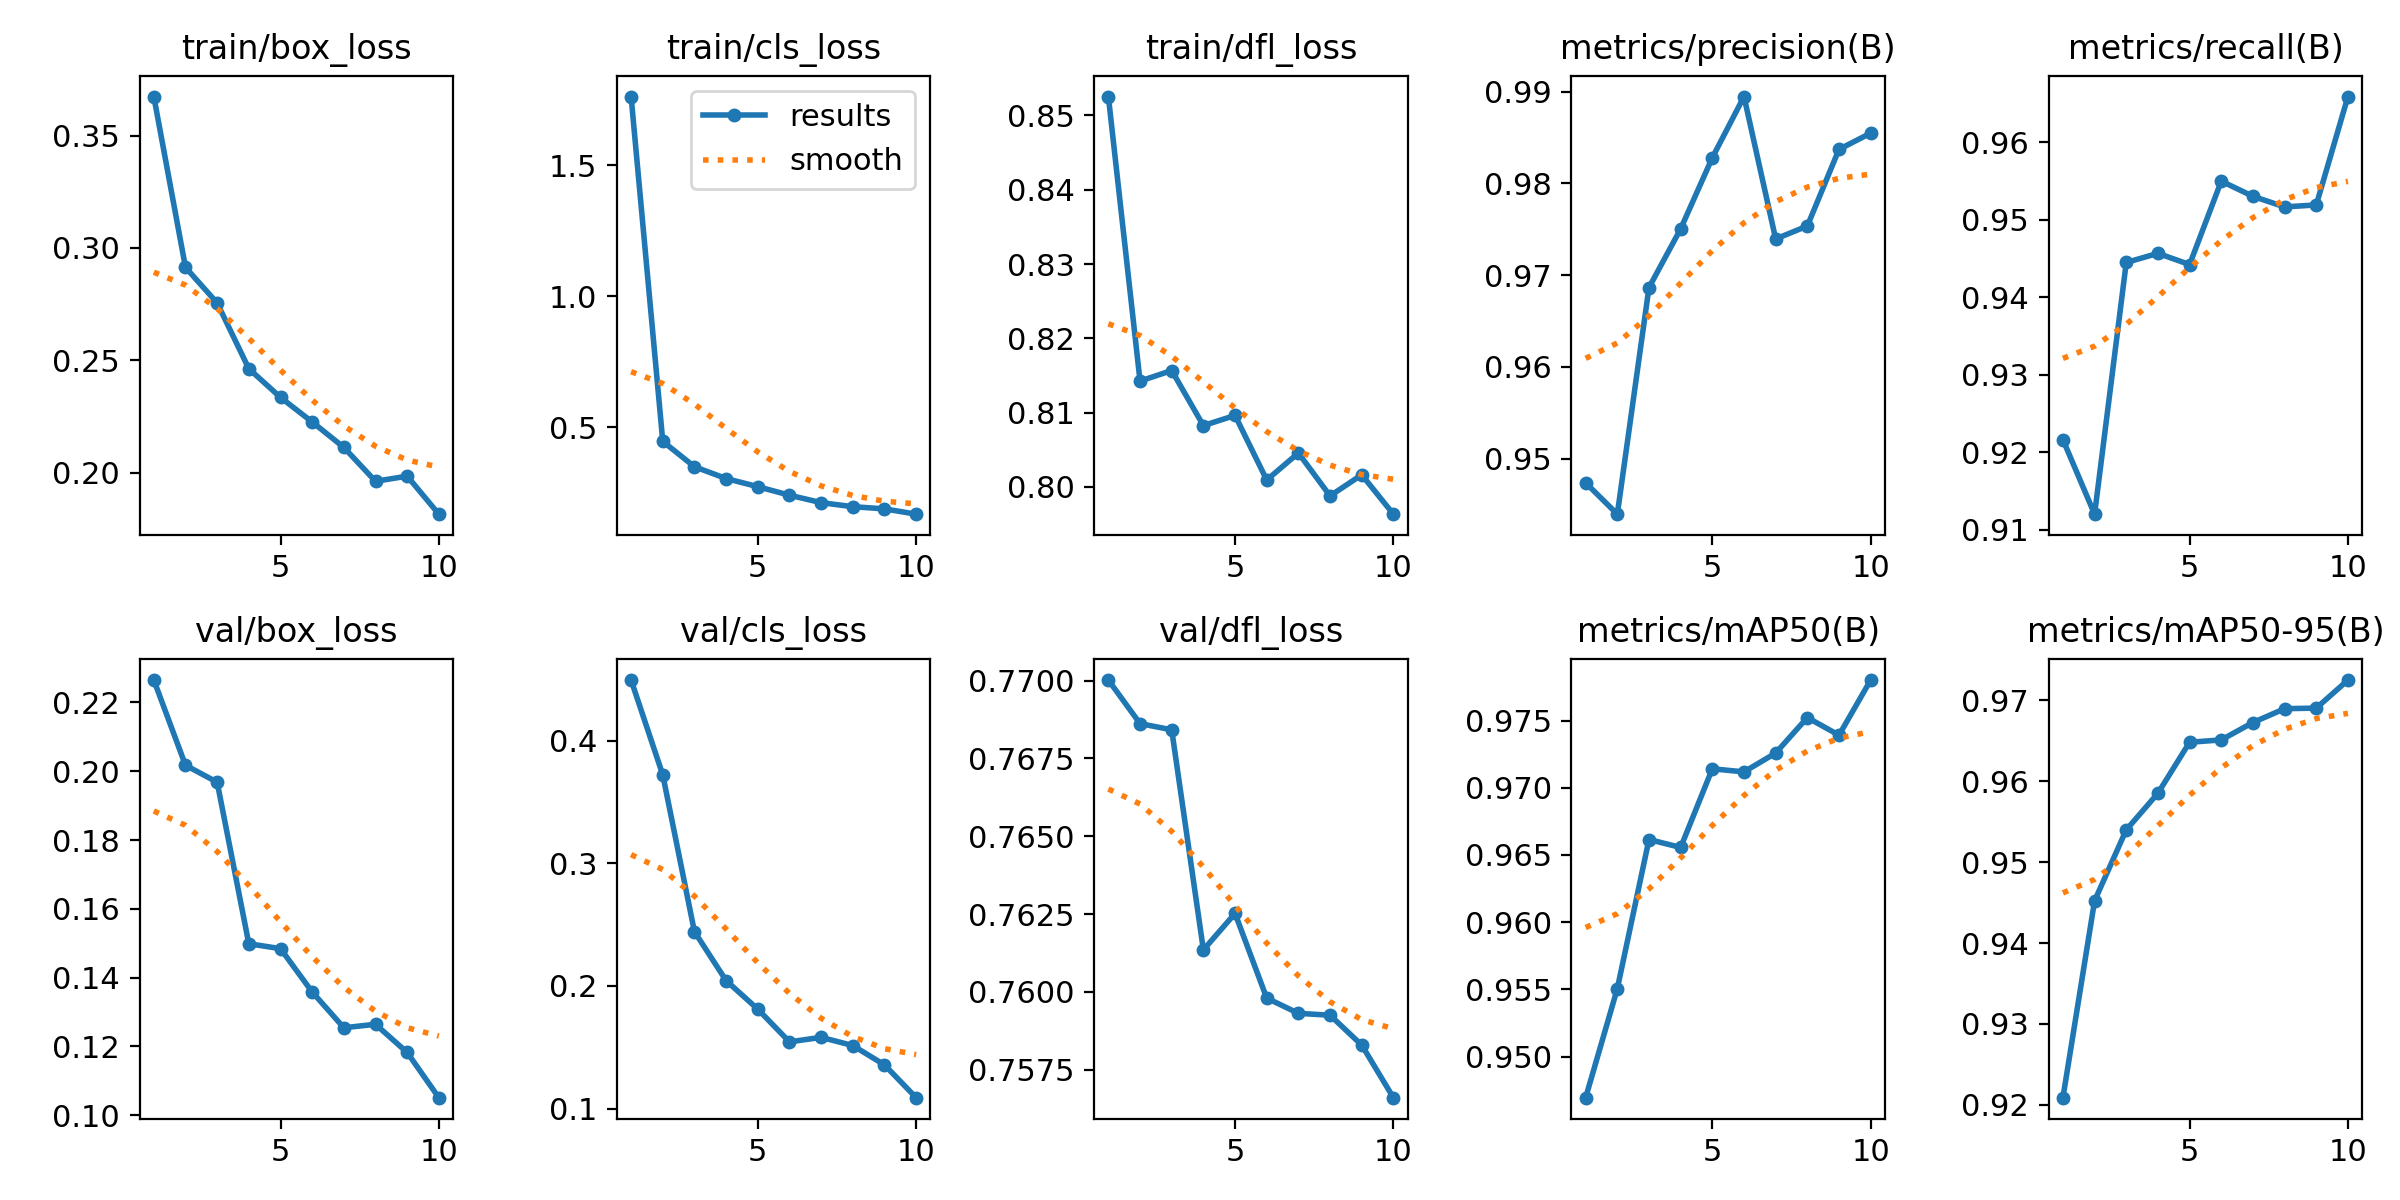

In [ ]:
Image(filename=f'{FINAL_GDRIVE_PATH}/results.png', width=600)

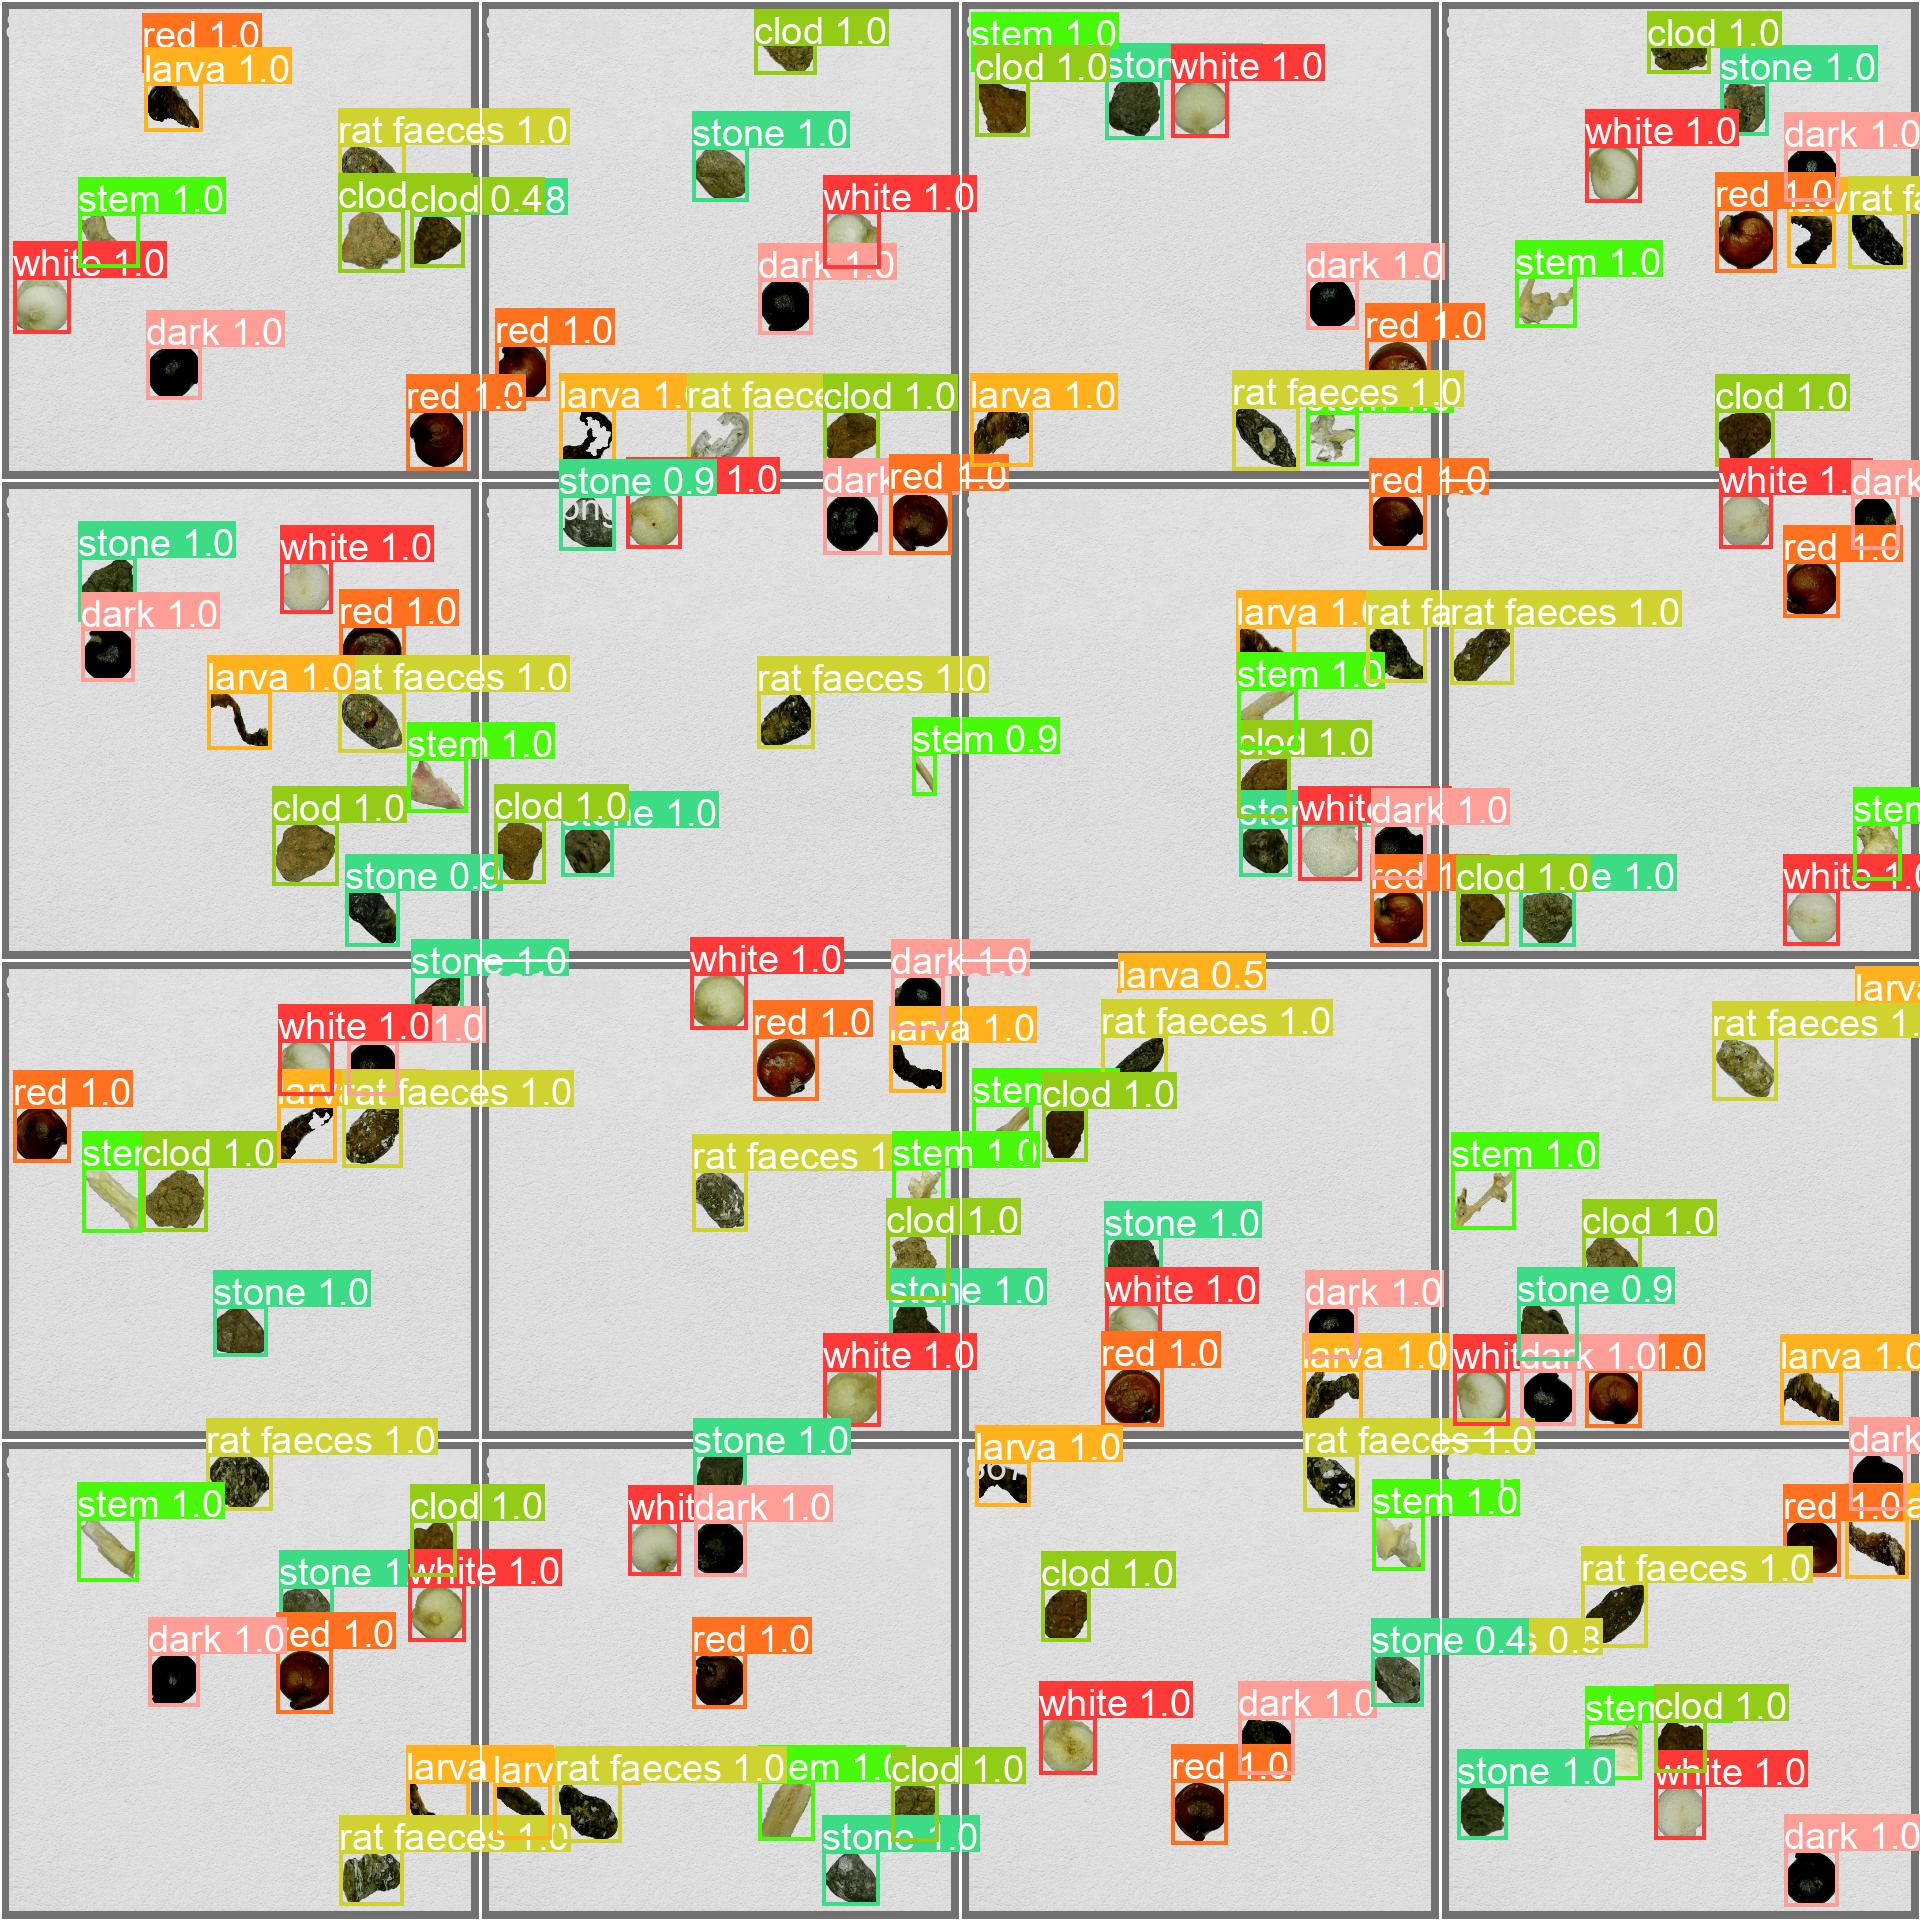

In [ ]:
Image(filename=f'{FINAL_GDRIVE_PATH}/val_batch0_pred.jpg', width=600)

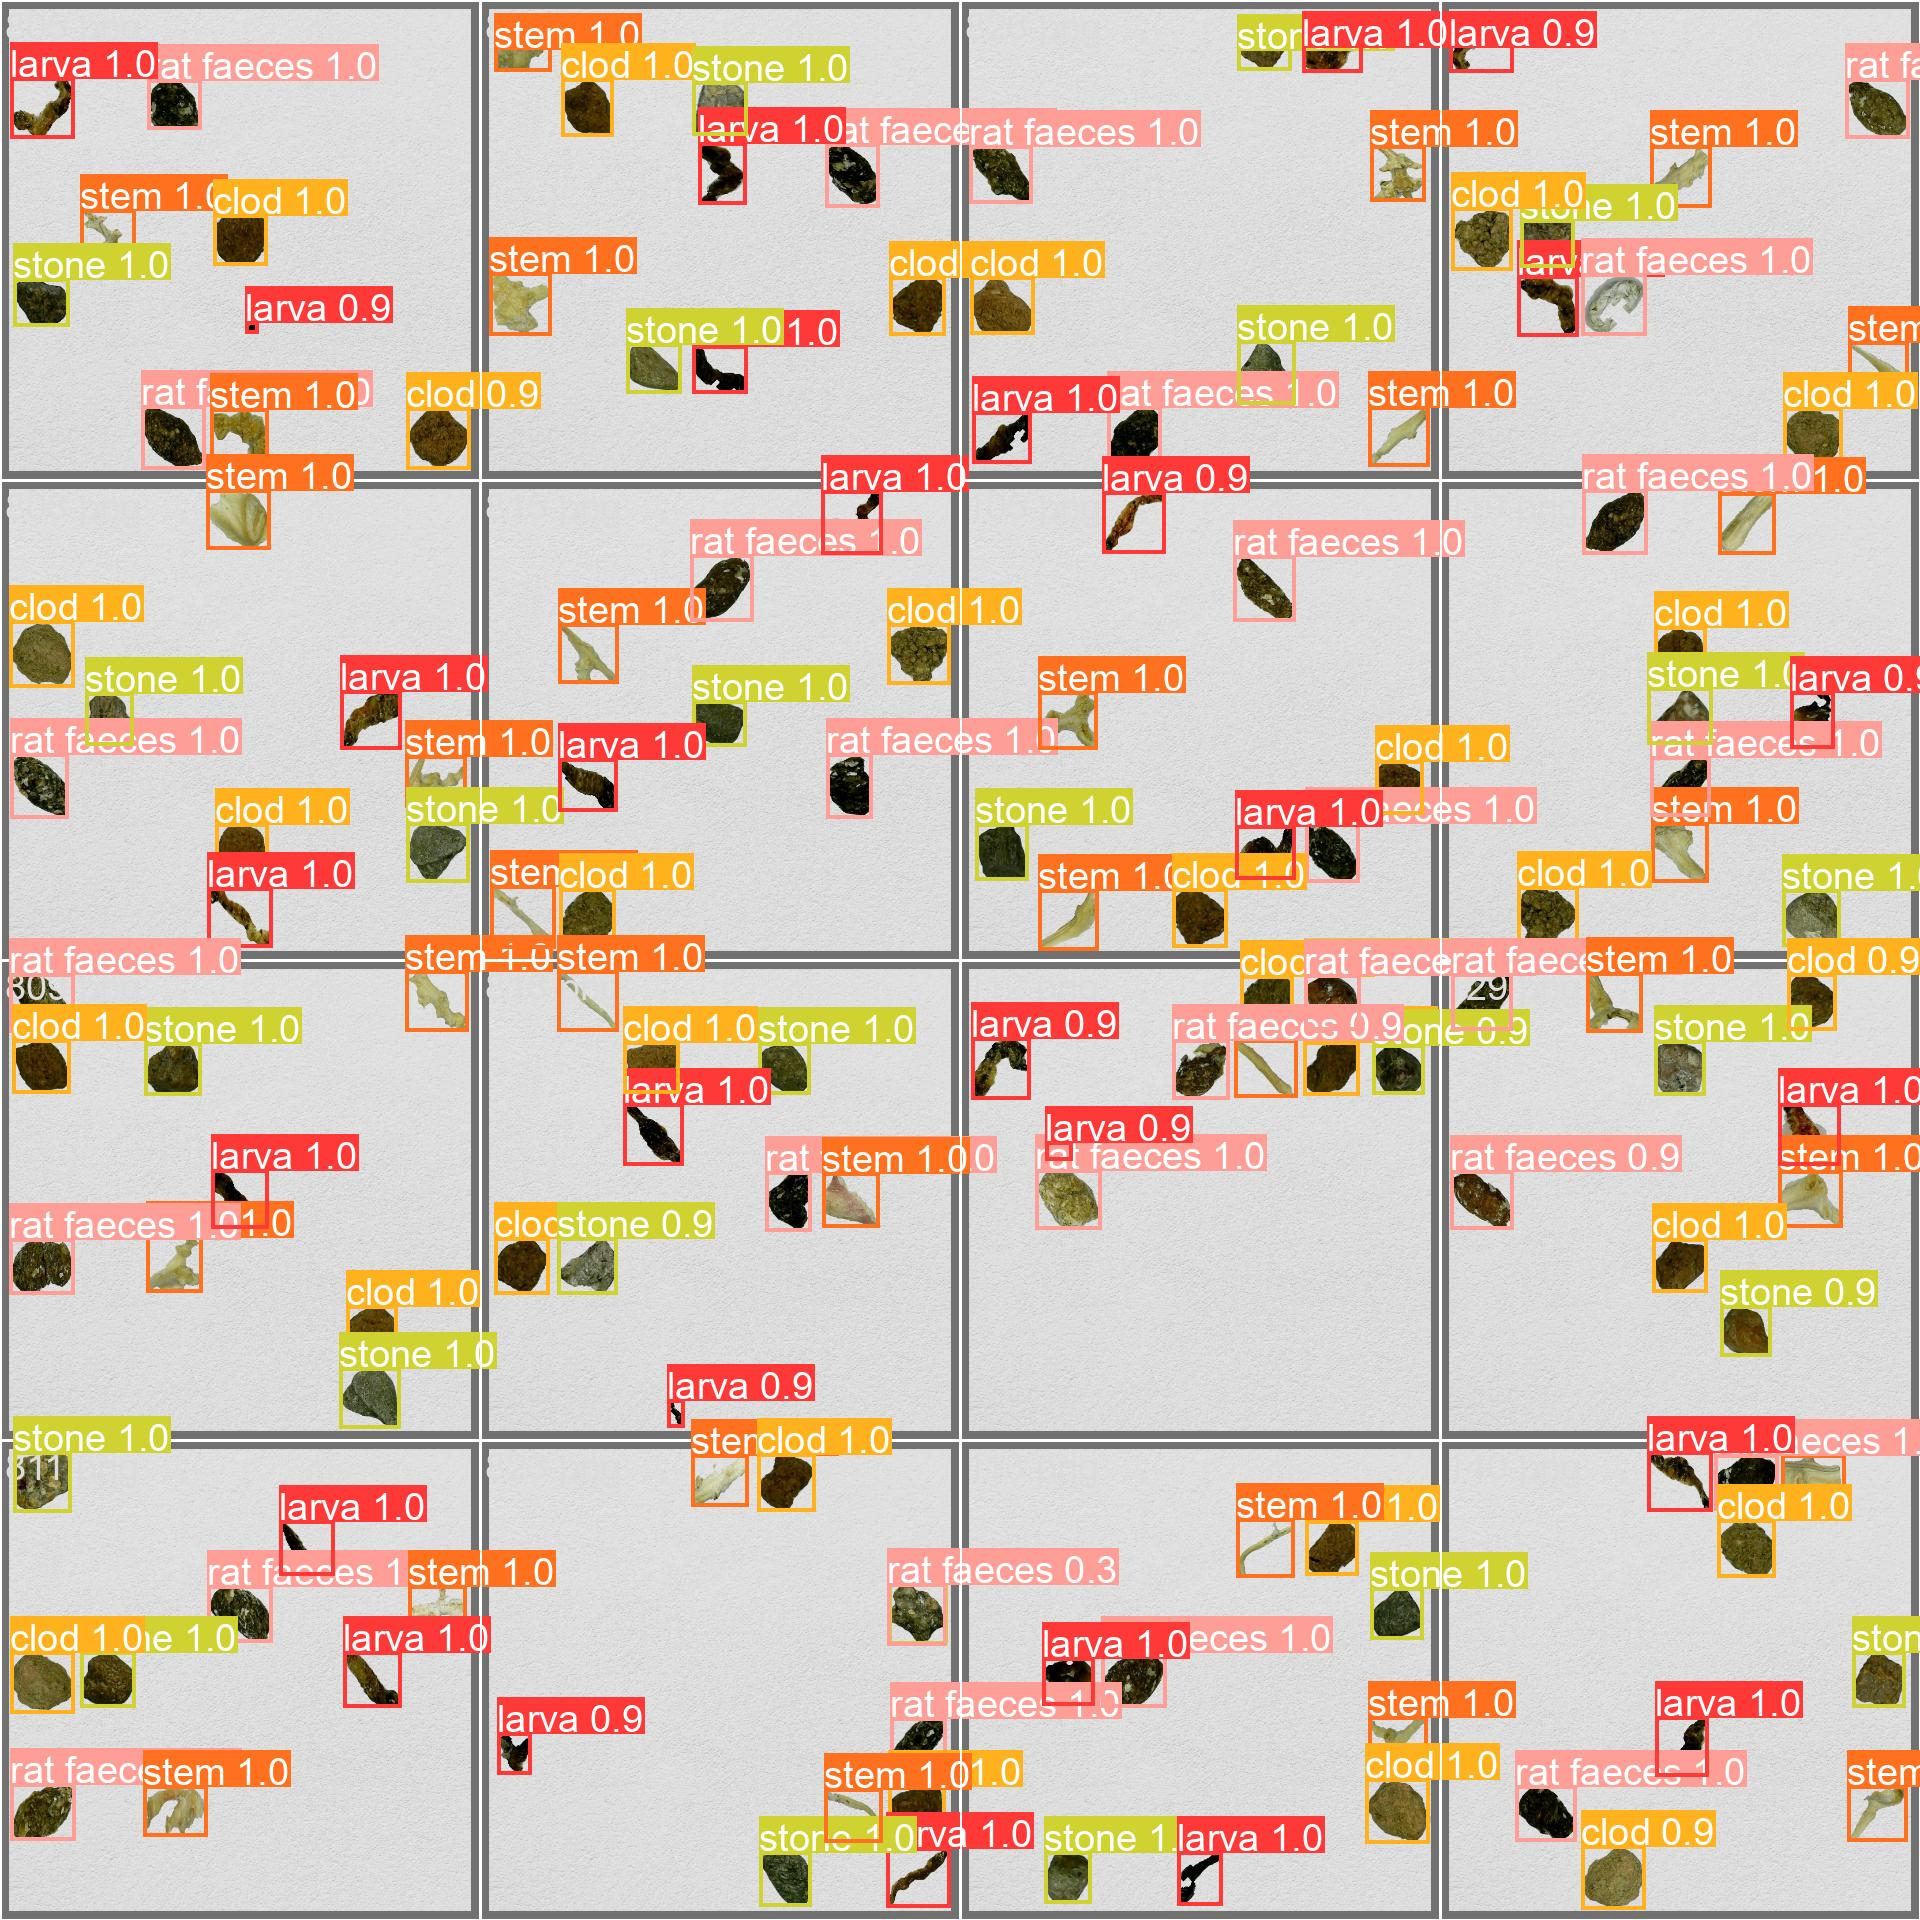

In [14]:
Image(filename=f'{FINAL_GDRIVE_PATH}/val_batch0_pred.jpg', width=600)

## 6. Evaluate Custom Model
<a name="eval"></a>

In [ ]:
%cd {HOME}

MODEL_PATH = os.path.join(FINAL_GDRIVE_PATH,"weights","best.pt")
!yolo task=detect mode=val model="$MODEL_PATH" data=/content/augmented_dataset/data.yaml

/content
Ultralytics YOLOv8.1.24 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (Tesla V100-SXM2-16GB, 16151MiB)
Model summary (fused): 168 layers, 11128680 parameters, 0 gradients, 28.5 GFLOPs
val: Scanning /content/augmented_dataset/val/labels.cache... 266 images, 0 backgrounds, 0 corrupt: 100% 266/266 [00:00<?, ?it/s]
/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 17/17 [00:24<00:00,  1.44s/it]
                   all        266       2394      0.985      0.967      0.978      0.973
                 white        266        303      0.992       0.99      0.995      0.994
                  dark        266        300      0.998          1      0.995      0.995
                   red        266        294      0.988  

In [16]:
%cd {HOME}

MODEL_PATH = os.path.join(FINAL_GDRIVE_PATH,"weights","best.pt")
!yolo task=detect mode=val model="$MODEL_PATH" data=/content/augmented_dataset_2/data.yaml

/content
Ultralytics YOLOv8.1.24 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 168 layers, 11127519 parameters, 0 gradients, 28.4 GFLOPs
val: Scanning /content/augmented_dataset_2/val/labels.cache... 166 images, 0 backgrounds, 0 corrupt: 100% 166/166 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 11/11 [00:10<00:00,  1.04it/s]
                   all        166       1494      0.988      0.988      0.993      0.991
                 larva        166        307      0.993      0.993      0.994      0.985
            rat faeces        166        291      0.967          1      0.995      0.994
                  stem        166        306          1      0.982       0.99      0.989
                  clod        166        296      0.978          1      0.994      0.993
                 stone        166        294          1      0.964      0.994      0.994
Speed: 2.1ms preprocess, 8.7ms 

## 7. Inference with Custom Model
<a name="inference"></a>

In [17]:
%cd {HOME}
!yolo task=detect mode=predict model="$MODEL_PATH" conf=0.25 source=/content/augmented_dataset_2/test/images save=True

/content
Ultralytics YOLOv8.1.24 🚀 Python-3.10.12 torch-2.3.1+cu121 CUDA:0 (NVIDIA L4, 22700MiB)
Model summary (fused): 168 layers, 11127519 parameters, 0 gradients, 28.4 GFLOPs

image 1/1 /content/augmented_dataset_2/test/images/285.png: 800x800 2 larvas, 2 rat faecess, 2 stems, 2 clods, 1 stone, 7.1ms
Speed: 7.5ms preprocess, 7.1ms inference, 583.0ms postprocess per image at shape (1, 3, 800, 800)
Results saved to runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


**NOTE:** Let's take a look at few results.

In [ ]:
import glob
from IPython.display import Image, display

for image_path in glob.glob(f'{HOME}/runs/detect/predict/*.png')[:3]:
  display(Image(filename=image_path, width=600))
  print("\n")

Output hidden; open in https://colab.research.google.com to view.

In [18]:
import glob
from IPython.display import Image, display

for image_path in glob.glob(f'{HOME}/runs/detect/predict/*.png')[:3]:
  display(Image(filename=image_path, width=600))
  print("\n")

## 8. Model deployment
<a name="deploy"></a>

In [ ]:
# It's important to downgrade tensorflow to export the model
!pip uninstall tensorflow
!pip install tensorflow==2.13.1

Found existing installation: tensorflow 2.15.0
Uninstalling tensorflow-2.15.0:
  Would remove:
    /usr/local/bin/estimator_ckpt_converter
    /usr/local/bin/import_pb_to_tensorboard
    /usr/local/bin/saved_model_cli
    /usr/local/bin/tensorboard
    /usr/local/bin/tf_upgrade_v2
    /usr/local/bin/tflite_convert
    /usr/local/bin/toco
    /usr/local/bin/toco_from_protos
    /usr/local/lib/python3.10/dist-packages/tensorflow-2.15.0.dist-info/*
    /usr/local/lib/python3.10/dist-packages/tensorflow/*
Proceed (Y/n)? Y
Y
  Successfully uninstalled tensorflow-2.15.0


In [ ]:
!pip show tensorflow

Name: tensorflow
Version: 2.13.1
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.10/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google-pasta, grpcio, h5py, keras, libclang, numpy, opt-einsum, packaging, protobuf, setuptools, six, tensorboard, tensorflow-estimator, tensorflow-io-gcs-filesystem, termcolor, typing-extensions, wrapt
Required-by: dopamine-rl, tf_keras


In [ ]:
import os
from google.colab import drive

# Mount Gdrive
drive.mount('/content/gdrive')

MODEL_NAME = "yolov8s" # options:yolov8s, yolov8n, yolov8m, yolov8x, yolov8l
GDRIVE_CHECKPOINTS_PATH = os.path.join("/content/gdrive/Shareddrives/QuinoaInspector 🌾/experiments/")
EXPERIMENT_NAME = MODEL_NAME + "_id1" # Change here the experiment name
FINAL_GDRIVE_PATH = os.path.join(GDRIVE_CHECKPOINTS_PATH, EXPERIMENT_NAME)
MODEL_PATH = os.path.join(FINAL_GDRIVE_PATH,"weights","best.pt")

!pip install ultralytics==8.1.24
!yolo export model="$MODEL_PATH" format=tflite

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.5.0
    Uninstalling typing_extensions-4.5.0:
      Successfully uninstalled typing_extensions-4.5.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.13.1 requires typing-extensions<4.6.0,>=3.6.6, but you have typing-extensions 4.11.0 which is incompatible.
tf-keras 2.15.1 requires tensorflow<2.16,>=2.15, but you have tensorflow 2.13.1 which is incompatible.
Ultralytics YOLOv8.1.24 🚀 Python-3.10.12 torch-2.2.1+cu121 CPU (Intel Xeon 2.30GHz)
Model summary (fused): 168 layers, 11127132 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from '/content/gdrive/Shareddrives/QuinoaInspector 🌾/experiments/yolov8s_id1/weights/best.